# Amazon.com Employee Access Prediction

## Project Objective
Design an algorithm to accurately predict the access status to certain resources of employees

## Problem Statement
When employees start working at an organization, they need computer access to fulfill their role. This access discovery cycle wastes time and money. We aim to build models that automatically determine access privileges based on employee roles and current access data.

## Analysis Tasks
1. Understand the type of data
2. Identify the output variable
3. Identify factors affecting the output variable
4. Check for biases in the dataset
5. Perform train-test split
6. Predict accuracy using classification models
7. Compare accuracy of different models

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                           f1_score, confusion_matrix, classification_report,
                           roc_auc_score, roc_curve)
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load and Understand the Data

In [2]:
# Load the datasets
train_df = pd.read_csv('../data/train/train.csv')
test_df = pd.read_csv('../data/test/test.csv')

print(f"Training data shape: {train_df.shape}")
print(f"Test data shape: {test_df.shape}")

print("\nFirst 5 rows of training data:")
train_df.head()

Training data shape: (32769, 10)
Test data shape: (912363, 10)

First 5 rows of training data:


,ACTION,RESOURCE,MGR_ID,ROLE_ROLLUP_1,ROLE_ROLLUP_2,ROLE_DEPTNAME,ROLE_TITLE,ROLE_FAMILY_DESC,ROLE_FAMILY,ROLE_CODE
0,1,39353,85475,117961,118300,123472,117905,117906,290919,117908
1,1,17183,1540,117961,118343,123125,118536,118536,308574,118539
2,1,36724,14457,118219,118220,117884,117879,267952,19721,117880
3,1,36135,5396,117961,118343,119993,118321,240983,290919,118322
4,1,42680,5905,117929,117930,119569,119323,123932,19793,119325


In [3]:
# Understanding data types
print("Dataset Information:")
print(train_df.info())

print("\nData Types:")
print(train_df.dtypes)

print("\nStatistical Summary:")
train_df.describe()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32769 entries, 0 to 32768
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   ACTION            32769 non-null  int64
 1   RESOURCE          32769 non-null  int64
 2   MGR_ID            32769 non-null  int64
 3   ROLE_ROLLUP_1     32769 non-null  int64
 4   ROLE_ROLLUP_2     32769 non-null  int64
 5   ROLE_DEPTNAME     32769 non-null  int64
 6   ROLE_TITLE        32769 non-null  int64
 7   ROLE_FAMILY_DESC  32769 non-null  int64
 8   ROLE_FAMILY       32769 non-null  int64
 9   ROLE_CODE         32769 non-null  int64
dtypes: int64(10)
memory usage: 2.5 MB
None

Data Types:
ACTION              int64
RESOURCE            int64
MGR_ID              int64
ROLE_ROLLUP_1       int64
ROLE_ROLLUP_2       int64
ROLE_DEPTNAME       int64
ROLE_TITLE          int64
ROLE_FAMILY_DESC    int64
ROLE_FAMILY         int64
ROLE_CODE           int64
dtype: object

,ACTION,RESOURCE,MGR_ID,ROLE_ROLLUP_1,ROLE_ROLLUP_2,ROLE_DEPTNAME,ROLE_TITLE,ROLE_FAMILY_DESC,ROLE_FAMILY,ROLE_CODE
count,32769.000000,32769.000000,32769.000000,32769.000000,32769.000000,32769.000000,32769.000000,32769.000000,32769.000000,32769.000000
mean,0.942110,42923.916171,25988.957979,116952.627788,118301.823156,118912.779914,125916.152644,170178.369648,183703.408893,119789.430132
std,0.233539,34173.892702,35928.031650,10875.563591,4551.588572,18961.322917,31036.465825,69509.462130,100488.407413,5784.275516
min,0.000000,0.000000,25.000000,4292.000000,23779.000000,4674.000000,117879.000000,4673.000000,3130.000000,117880.000000
25%,1.000000,20299.000000,4566.000000,117961.000000,118102.000000,118395.000000,118274.000000,117906.000000,118363.000000,118232.000000
50%,1.000000,35376.000000,13545.000000,117961.000000,118300.000000,118921.000000,118568.000000,128696.000000,119006.000000,118570.000000
75%,1.000000,74189.000000,42034.000000,117961.000000,118386.000000,120535.000000,120006.000000,235280.000000,290919.000000,119348.000000
max,1.000000,312153.000000,311696.000000,311178.000000,286791.000000,286792.000000,311867.000000,311867.000000,308574.000000,270691.000000


In [5]:
# Check for missing values
print("Missing Values Analysis:")
missing_values = train_df.isnull().sum()
print(missing_values)

if missing_values.sum() == 0:
    print("\nNo missing values found in the dataset!")
else:
    print(f"\n⚠️ Total missing values: {missing_values.sum()}")

Missing Values Analysis:
ACTION              0
RESOURCE            0
MGR_ID              0
ROLE_ROLLUP_1       0
ROLE_ROLLUP_2       0
ROLE_DEPTNAME       0
ROLE_TITLE          0
ROLE_FAMILY_DESC    0
ROLE_FAMILY         0
ROLE_CODE           0
dtype: int64

No missing values found in the dataset!


## 2. Identify the Output Variable

Target Variable: ACTION
Description: Binary classification (1 = Access Granted, 0 = Access Denied)

Target Distribution:
ACTION
1    30872
0     1897
Name: count, dtype: int64

Access Granted Rate: 94.2%
Access Denied Rate: 5.8%


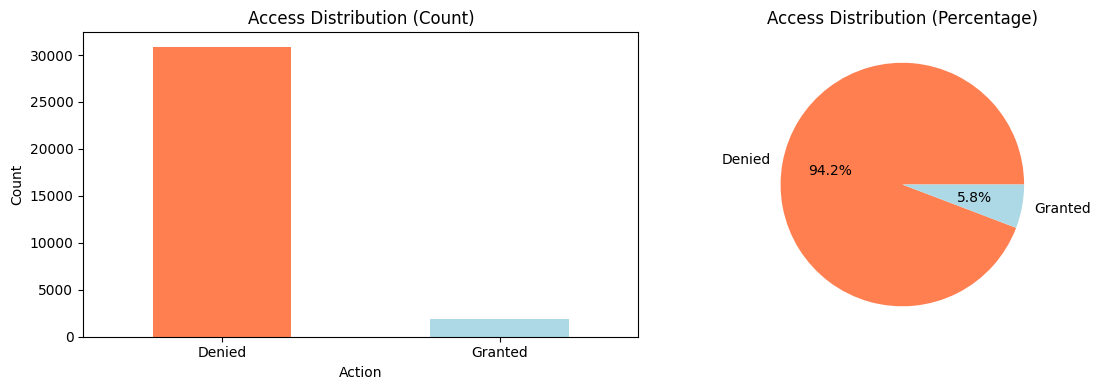

In [7]:
# Identify target variable
target_column = 'ACTION'
print(f"Target Variable: {target_column}")
print(f"Description: Binary classification (1 = Access Granted, 0 = Access Denied)\n")

# Target variable distribution
target_counts = train_df[target_column].value_counts()
print("Target Distribution:")
print(target_counts)

access_granted_rate = train_df[target_column].mean()
print(f"\nAccess Granted Rate: {access_granted_rate:.1%}")
print(f"Access Denied Rate: {1-access_granted_rate:.1%}")

# Visualize target distribution
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
target_counts.plot(kind='bar', color=['coral', 'lightblue'])
plt.title('Access Distribution (Count)')
plt.xlabel('Action')
plt.ylabel('Count')
plt.xticks([0, 1], ['Denied', 'Granted'], rotation=0)

plt.subplot(1, 2, 2)
plt.pie(target_counts.values, labels=['Denied', 'Granted'], autopct='%1.1f%%', 
        colors=['coral', 'lightblue'])
plt.title('Access Distribution (Percentage)')

plt.tight_layout()
plt.show()

## 3. Identify Factors Affecting the Output Variable

In [8]:
# Identify input features
feature_columns = [col for col in train_df.columns if col != target_column]
print(f"Input Features ({len(feature_columns)} total):")
print(feature_columns)

# Feature descriptions
feature_descriptions = {
    'RESOURCE': 'ID of the resource being requested',
    'MGR_ID': 'Manager ID of the requesting employee',
    'ROLE_ROLLUP_1': 'Company role category (highest level)',
    'ROLE_ROLLUP_2': 'Company role category (second level)',
    'ROLE_DEPTNAME': 'Department name associated with the role',
    'ROLE_TITLE': 'Business title of the employee role',
    'ROLE_FAMILY_DESC': 'Extended description of the role family',
    'ROLE_FAMILY': 'Role family category',
    'ROLE_CODE': 'Company-specific role code'
}

print("\nFeature Analysis:")
feature_analysis = []
for feature in feature_columns:
    unique_count = train_df[feature].nunique()
    unique_ratio = unique_count / len(train_df)
    description = feature_descriptions.get(feature, 'Role-related feature')
    feature_analysis.append({
        'Feature': feature,
        'Unique_Values': unique_count,
        'Unique_Ratio': f"{unique_ratio:.1%}",
        'Description': description
    })
    print(f"• {feature}: {unique_count:,} unique values ({unique_ratio:.1%} of dataset)")
    print(f"  {description}")

# Convert to DataFrame for better visualization
feature_df = pd.DataFrame(feature_analysis)
feature_df

Input Features (9 total):
['RESOURCE', 'MGR_ID', 'ROLE_ROLLUP_1', 'ROLE_ROLLUP_2', 'ROLE_DEPTNAME', 'ROLE_TITLE', 'ROLE_FAMILY_DESC', 'ROLE_FAMILY', 'ROLE_CODE']

Feature Analysis:
• RESOURCE: 7,518 unique values (22.9% of dataset)
  ID of the resource being requested
• MGR_ID: 4,243 unique values (12.9% of dataset)
  Manager ID of the requesting employee
• ROLE_ROLLUP_1: 128 unique values (0.4% of dataset)
  Company role category (highest level)
• ROLE_ROLLUP_2: 177 unique values (0.5% of dataset)
  Company role category (second level)
• ROLE_DEPTNAME: 449 unique values (1.4% of dataset)
  Department name associated with the role
• ROLE_TITLE: 343 unique values (1.0% of dataset)
  Business title of the employee role
• ROLE_FAMILY_DESC: 2,358 unique values (7.2% of dataset)
  Extended description of the role family
• ROLE_FAMILY: 67 unique values (0.2% of dataset)
  Role family category
• ROLE_CODE: 343 unique values (1.0% of dataset)
  Company-specific role code


,Feature,Unique_Values,Unique_Ratio,Description
0,RESOURCE,7518,22.9%,ID of the resource being requested
1,MGR_ID,4243,12.9%,Manager ID of the requesting employee
2,ROLE_ROLLUP_1,128,0.4%,Company role category (highest level)
3,ROLE_ROLLUP_2,177,0.5%,Company role category (second level)
4,ROLE_DEPTNAME,449,1.4%,Department name associated with the role
5,ROLE_TITLE,343,1.0%,Business title of the employee role
6,ROLE_FAMILY_DESC,2358,7.2%,Extended description of the role family
7,ROLE_FAMILY,67,0.2%,Role family category
8,ROLE_CODE,343,1.0%,Company-specific role code


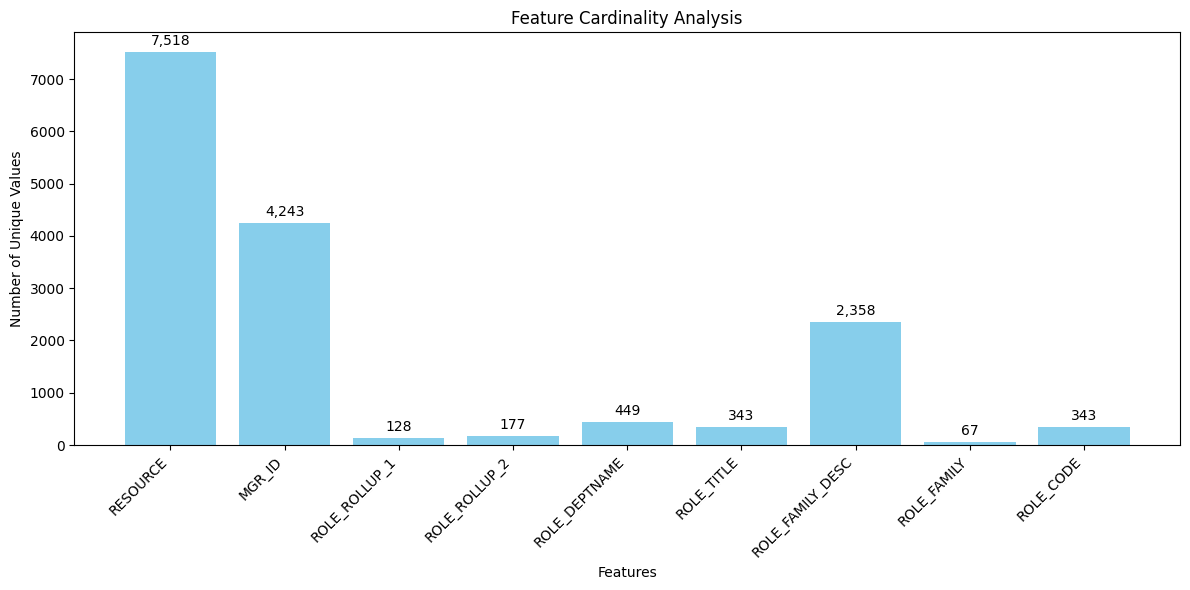

In [9]:
# Visualize feature cardinality
plt.figure(figsize=(12, 6))
unique_counts = [train_df[col].nunique() for col in feature_columns]
bars = plt.bar(range(len(feature_columns)), unique_counts, color='skyblue')
plt.xlabel('Features')
plt.ylabel('Number of Unique Values')
plt.title('Feature Cardinality Analysis')
plt.xticks(range(len(feature_columns)), feature_columns, rotation=45, ha='right')

# Add value labels on bars
for bar, count in zip(bars, unique_counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(unique_counts)*0.01,
             f'{count:,}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

## 4. Check for Dataset Biases

In [10]:
print("DATASET BIAS ANALYSIS")
print("=" * 50)

# 1. Class Imbalance Analysis
print("1. Class Imbalance Analysis:")
class_ratio = train_df[target_column].mean()
print(f"   • Positive class (ACCESS GRANTED): {class_ratio:.1%}")
print(f"   • Negative class (ACCESS DENIED): {1-class_ratio:.1%}")

if class_ratio > 0.8 or class_ratio < 0.2:
    print("   ⚠️ SIGNIFICANT CLASS IMBALANCE DETECTED!")
    print("   Recommendation: Consider using SMOTE, class weights, or stratified sampling")
else:
    print("   Reasonable class balance")

# 2. Feature Distribution Analysis
print("\n2. Feature Distribution Analysis:")
high_cardinality_threshold = 0.5
high_cardinality_features = []

for feature in feature_columns:
    cardinality = train_df[feature].nunique()
    cardinality_ratio = cardinality / len(train_df)
    
    if cardinality_ratio > high_cardinality_threshold:
        high_cardinality_features.append(feature)
        print(f"   ⚠️ {feature}: High cardinality ({cardinality:,} unique, {cardinality_ratio:.1%})")

if not high_cardinality_features:
    print("   No concerning high cardinality features")

# 3. Data Quality Check
print("\n3. Data Quality Analysis:")
print(f"   • Missing values: {train_df.isnull().sum().sum()} (None found)")
print(f"   • Duplicate rows: {train_df.duplicated().sum()}")
print(f"   • Data types: All numeric (Consistent)")

# 4. Statistical Analysis
print("\n4. Statistical Distribution Analysis:")
for feature in feature_columns[:3]:  # Show first 3 features as examples
    skewness = train_df[feature].skew()
    print(f"   • {feature}: Skewness = {skewness:.2f}")
    if abs(skewness) > 2:
        print(f"     ⚠️ Highly skewed distribution")
    elif abs(skewness) > 1:
        print(f"     ⚠️ Moderately skewed distribution")
    else:
        print(f"     Reasonably normal distribution")

DATASET BIAS ANALYSIS
1. Class Imbalance Analysis:
   • Positive class (ACCESS GRANTED): 94.2%
   • Negative class (ACCESS DENIED): 5.8%
   ⚠️ SIGNIFICANT CLASS IMBALANCE DETECTED!
   Recommendation: Consider using SMOTE, class weights, or stratified sampling

2. Feature Distribution Analysis:
   No concerning high cardinality features

3. Data Quality Analysis:
   • Missing values: 0 (None found)
   • Duplicate rows: 0
   • Data types: All numeric (Consistent)

4. Statistical Distribution Analysis:
   • RESOURCE: Skewness = 2.81
     ⚠️ Highly skewed distribution
   • MGR_ID: Skewness = 3.36
     ⚠️ Highly skewed distribution
   • ROLE_ROLLUP_1: Skewness = -6.46
     ⚠️ Highly skewed distribution


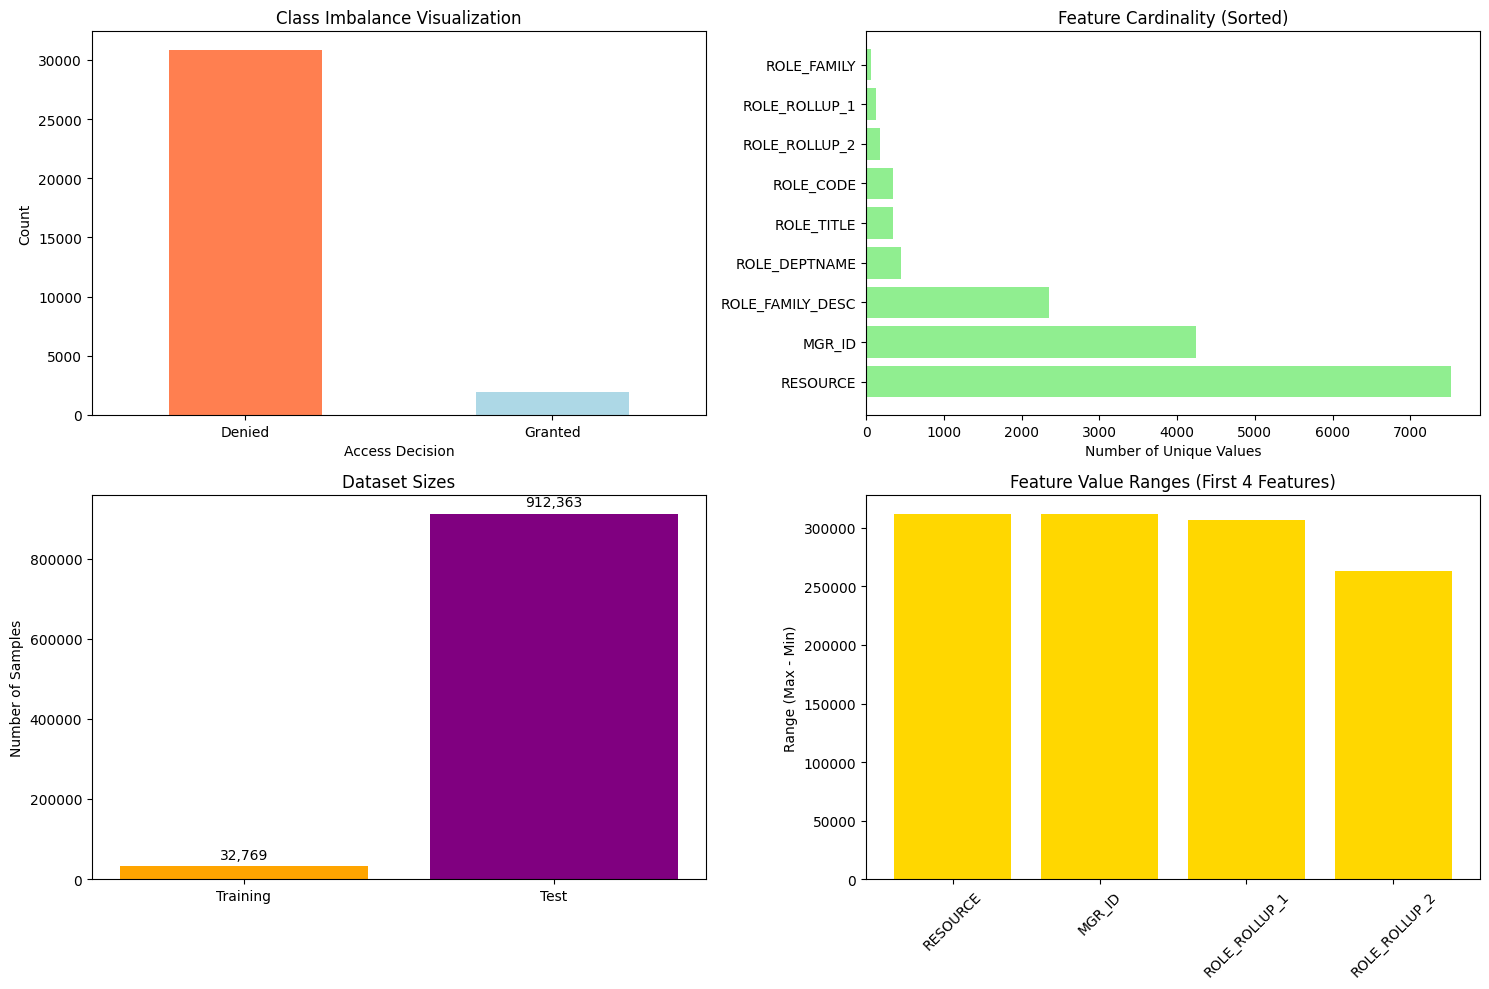

In [12]:
# Visualize potential biases
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Class distribution
target_counts.plot(kind='bar', ax=axes[0,0], color=['coral', 'lightblue'])
axes[0,0].set_title('Class Imbalance Visualization')
axes[0,0].set_xlabel('Access Decision')
axes[0,0].set_ylabel('Count')
axes[0,0].set_xticklabels(['Denied', 'Granted'], rotation=0)

# 2. Feature cardinality comparison
cardinality_data = [(col, train_df[col].nunique()) for col in feature_columns]
cardinality_data.sort(key=lambda x: x[1], reverse=True)
features, counts = zip(*cardinality_data)

axes[0,1].barh(features, counts, color='lightgreen')
axes[0,1].set_title('Feature Cardinality (Sorted)')
axes[0,1].set_xlabel('Number of Unique Values')

# 3. Sample size adequacy
sample_sizes = [len(train_df), len(test_df)]
dataset_labels = ['Training', 'Test']
axes[1,0].bar(dataset_labels, sample_sizes, color=['orange', 'purple'])
axes[1,0].set_title('Dataset Sizes')
axes[1,0].set_ylabel('Number of Samples')
for i, size in enumerate(sample_sizes):
    axes[1,0].text(i, size + max(sample_sizes)*0.02, f'{size:,}', ha='center')

# 4. Feature value ranges (first 4 features)
feature_ranges = []
for feature in feature_columns[:4]:
    feature_range = train_df[feature].max() - train_df[feature].min()
    feature_ranges.append(feature_range)

axes[1,1].bar(feature_columns[:4], feature_ranges, color='gold')
axes[1,1].set_title('Feature Value Ranges (First 4 Features)')
axes[1,1].set_ylabel('Range (Max - Min)')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 5. Perform Train-Test Split

In [15]:
# Prepare features and target
X = train_df[feature_columns]
y = train_df[target_column]

print(f"Original dataset shape: {X.shape}")
print(f"Target distribution: {y.value_counts().to_dict()}")

# Perform stratified train-validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nAfter Train-Validation Split:")
print(f"Training set: {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation set: {X_val.shape[0]:,} samples ({X_val.shape[0]/len(X)*100:.1f}%)")

print(f"\nTarget Distribution Check:")
print(f"Training - Granted: {y_train.mean():.1%}, Denied: {1-y_train.mean():.1%}")
print(f"Validation - Granted: {y_val.mean():.1%}, Denied: {1-y_val.mean():.1%}")

if abs(y_train.mean() - y_val.mean()) < 0.01:
    print("Stratification successful - similar distributions maintained")
else:
    print("⚠️ Stratification may need adjustment")

Original dataset shape: (32769, 9)
Target distribution: {1: 30872, 0: 1897}

After Train-Validation Split:
Training set: 26,215 samples (80.0%)
Validation set: 6,554 samples (20.0%)

Target Distribution Check:
Training - Granted: 94.2%, Denied: 5.8%
Validation - Granted: 94.2%, Denied: 5.8%
Stratification successful - similar distributions maintained


In [16]:
# Feature scaling for algorithms that require it
print("Applying Feature Scaling...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print(f"Scaled training data shape: {X_train_scaled.shape}")
print(f"Scaled validation data shape: {X_val_scaled.shape}")

# Verify scaling
print(f"\nScaling Verification (first 3 features):")
print(f"Mean: {np.mean(X_train_scaled, axis=0)[:3]}")
print(f"Std: {np.std(X_train_scaled, axis=0)[:3]}")
print("Features successfully standardized (mean≈0, std≈1)")

Applying Feature Scaling...
Scaled training data shape: (26215, 9)
Scaled validation data shape: (6554, 9)

Scaling Verification (first 3 features):
Mean: [-9.35780582e-17 -2.90017443e-17 -1.43721261e-16]
Std: [1. 1. 1.]
Features successfully standardized (mean≈0, std≈1)


## 6. Apply Classification Models and Predict Accuracy

In [19]:
# Define classification models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=15),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, max_depth=15),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42, n_estimators=100),
    'SVM': SVC(random_state=42, probability=True, kernel='rbf'),
    'Naive Bayes': GaussianNB(),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5)
}

print(f"Training {len(models)} classification models...\n")

# Dictionary to store results
results = {}

# Train and evaluate each model
for name, model in models.items():
    print(f"Training {name}...")
    
    # Determine if model needs scaled features
    needs_scaling = name in ['Logistic Regression', 'SVM', 'Naive Bayes', 'K-Nearest Neighbors']
    
    # Select appropriate feature sets
    if needs_scaling:
        X_tr, X_v = X_train_scaled, X_val_scaled
    else:
        X_tr, X_v = X_train, X_val
    
    # Train model
    model.fit(X_tr, y_train)
    
    # Make predictions
    y_pred = model.predict(X_v)
    
    # Get probability predictions for ROC-AUC
    if hasattr(model, 'predict_proba'):
        y_pred_proba = model.predict_proba(X_v)[:, 1]
    else:
        y_pred_proba = y_pred  # For models without probability prediction
    
    # Calculate metrics
    accuracy = accuracy_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    
    try:
        auc_score = roc_auc_score(y_val, y_pred_proba)
    except ValueError:
        auc_score = roc_auc_score(y_val, y_pred)
    
    # Cross-validation for stability check
    cv_scores = cross_val_score(model, X_tr, y_train, cv=5, scoring='accuracy')
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()
    
    # Store results
    results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'AUC': auc_score,
        'CV_Mean': cv_mean,
        'CV_Std': cv_std,
        'predictions': y_pred,
        'probabilities': y_pred_proba
    }
    
    # Display results
    print(f"   Accuracy: {accuracy:.4f}")
    print(f"   Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")
    print(f"   AUC Score: {auc_score:.4f}")
    print(f"   Cross-validation: {cv_mean:.4f} ± {cv_std:.4f}\n")

print("All models trained successfully! ")

Training 7 classification models...

Training Logistic Regression...
   Accuracy: 0.9422
   Precision: 0.9422 | Recall: 1.0000 | F1: 0.9702
   AUC Score: 0.5130
   Cross-validation: 0.9421 ± 0.0001

Training Decision Tree...
   Accuracy: 0.9382
   Precision: 0.9606 | Recall: 0.9744 | F1: 0.9674
   AUC Score: 0.7553
   Cross-validation: 0.9353 ± 0.0032

Training Random Forest...
   Accuracy: 0.9469
   Precision: 0.9508 | Recall: 0.9951 | F1: 0.9725
   AUC Score: 0.8554
   Cross-validation: 0.9471 ± 0.0010

Training Gradient Boosting...
   Accuracy: 0.9419
   Precision: 0.9428 | Recall: 0.9989 | F1: 0.9700
   AUC Score: 0.7405
   Cross-validation: 0.9431 ± 0.0004

Training SVM...
   Accuracy: 0.9422
   Precision: 0.9422 | Recall: 1.0000 | F1: 0.9702
   AUC Score: 0.5776
   Cross-validation: 0.9421 ± 0.0001

Training Naive Bayes...
   Accuracy: 0.9056
   Precision: 0.9425 | Recall: 0.9582 | F1: 0.9503
   AUC Score: 0.5645
   Cross-validation: 0.9116 ± 0.0048

Training K-Nearest Neighbors.

## 7. Compare Model Accuracies and Performance

In [20]:
# Create comprehensive comparison DataFrame
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[model]['Accuracy'] for model in results.keys()],
    'Precision': [results[model]['Precision'] for model in results.keys()],
    'Recall': [results[model]['Recall'] for model in results.keys()],
    'F1-Score': [results[model]['F1-Score'] for model in results.keys()],
    'AUC': [results[model]['AUC'] for model in results.keys()],
    'CV_Mean': [results[model]['CV_Mean'] for model in results.keys()],
    'CV_Std': [results[model]['CV_Std'] for model in results.keys()]
})

# Sort by accuracy (descending)
comparison_df = comparison_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)

print("MODEL PERFORMANCE COMPARISON")
print("=" * 80)
print(comparison_df.round(4).to_string(index=False))

# Identify best model
best_model_name = comparison_df.iloc[0]['Model']
best_accuracy = comparison_df.iloc[0]['Accuracy']
print(f"\nBEST MODEL: {best_model_name} (Accuracy: {best_accuracy:.4f})")

comparison_df

MODEL PERFORMANCE COMPARISON
              Model  Accuracy  Precision  Recall  F1-Score    AUC  CV_Mean  CV_Std
      Random Forest    0.9469     0.9508  0.9951    0.9725 0.8554   0.9471  0.0010
Logistic Regression    0.9422     0.9422  1.0000    0.9702 0.5130   0.9421  0.0001
                SVM    0.9422     0.9422  1.0000    0.9702 0.5776   0.9421  0.0001
  Gradient Boosting    0.9419     0.9428  0.9989    0.9700 0.7405   0.9431  0.0004
      Decision Tree    0.9382     0.9606  0.9744    0.9674 0.7553   0.9353  0.0032
K-Nearest Neighbors    0.9379     0.9466  0.9900    0.9678 0.6860   0.9366  0.0017
        Naive Bayes    0.9056     0.9425  0.9582    0.9503 0.5645   0.9116  0.0048

BEST MODEL: Random Forest (Accuracy: 0.9469)


,Model,Accuracy,Precision,Recall,F1-Score,AUC,CV_Mean,CV_Std
0,Random Forest,0.946903,0.950797,0.995142,0.972464,0.855416,0.947130,0.001040
1,Logistic Regression,0.942173,0.942173,1.000000,0.970225,0.513023,0.942094,0.000093
2,SVM,0.942173,0.942173,1.000000,0.970225,0.577629,0.942132,0.000093
3,Gradient Boosting,0.941868,0.942831,0.998866,0.970040,0.740534,0.943124,0.000370
4,Decision Tree,0.938206,0.960568,0.974413,0.967441,0.755336,0.935342,0.003219
5,K-Nearest Neighbors,0.937901,0.946578,0.989960,0.967783,0.685992,0.936639,0.001729
6,Naive Bayes,0.905554,0.942498,0.958219,0.950293,0.564479,0.911615,0.004846


In [21]:
# Detailed classification report for best model
best_model = models[best_model_name]
if best_model_name in ['Logistic Regression', 'SVM', 'Naive Bayes', 'K-Nearest Neighbors']:
    best_predictions = best_model.predict(X_val_scaled)
else:
    best_predictions = best_model.predict(X_val)

print(f"DETAILED CLASSIFICATION REPORT - {best_model_name}")
print("=" * 60)
print(classification_report(y_val, best_predictions, 
                          target_names=['Access Denied', 'Access Granted']))

# Confusion matrix
cm = confusion_matrix(y_val, best_predictions)
print(f"\nCONFUSION MATRIX - {best_model_name}")
print("=" * 40)
print(f"                 Predicted")
print(f"Actual    Denied  Granted")
print(f"Denied     {cm[0,0]:4d}    {cm[0,1]:4d}")
print(f"Granted    {cm[1,0]:4d}    {cm[1,1]:4d}")

DETAILED CLASSIFICATION REPORT - Random Forest
                precision    recall  f1-score   support

 Access Denied       0.67      0.16      0.26       379
Access Granted       0.95      1.00      0.97      6175

      accuracy                           0.95      6554
     macro avg       0.81      0.58      0.62      6554
  weighted avg       0.93      0.95      0.93      6554


CONFUSION MATRIX - Random Forest
                 Predicted
Actual    Denied  Granted
Denied       61     318
Granted      30    6145


## 8. Comprehensive Visualizations

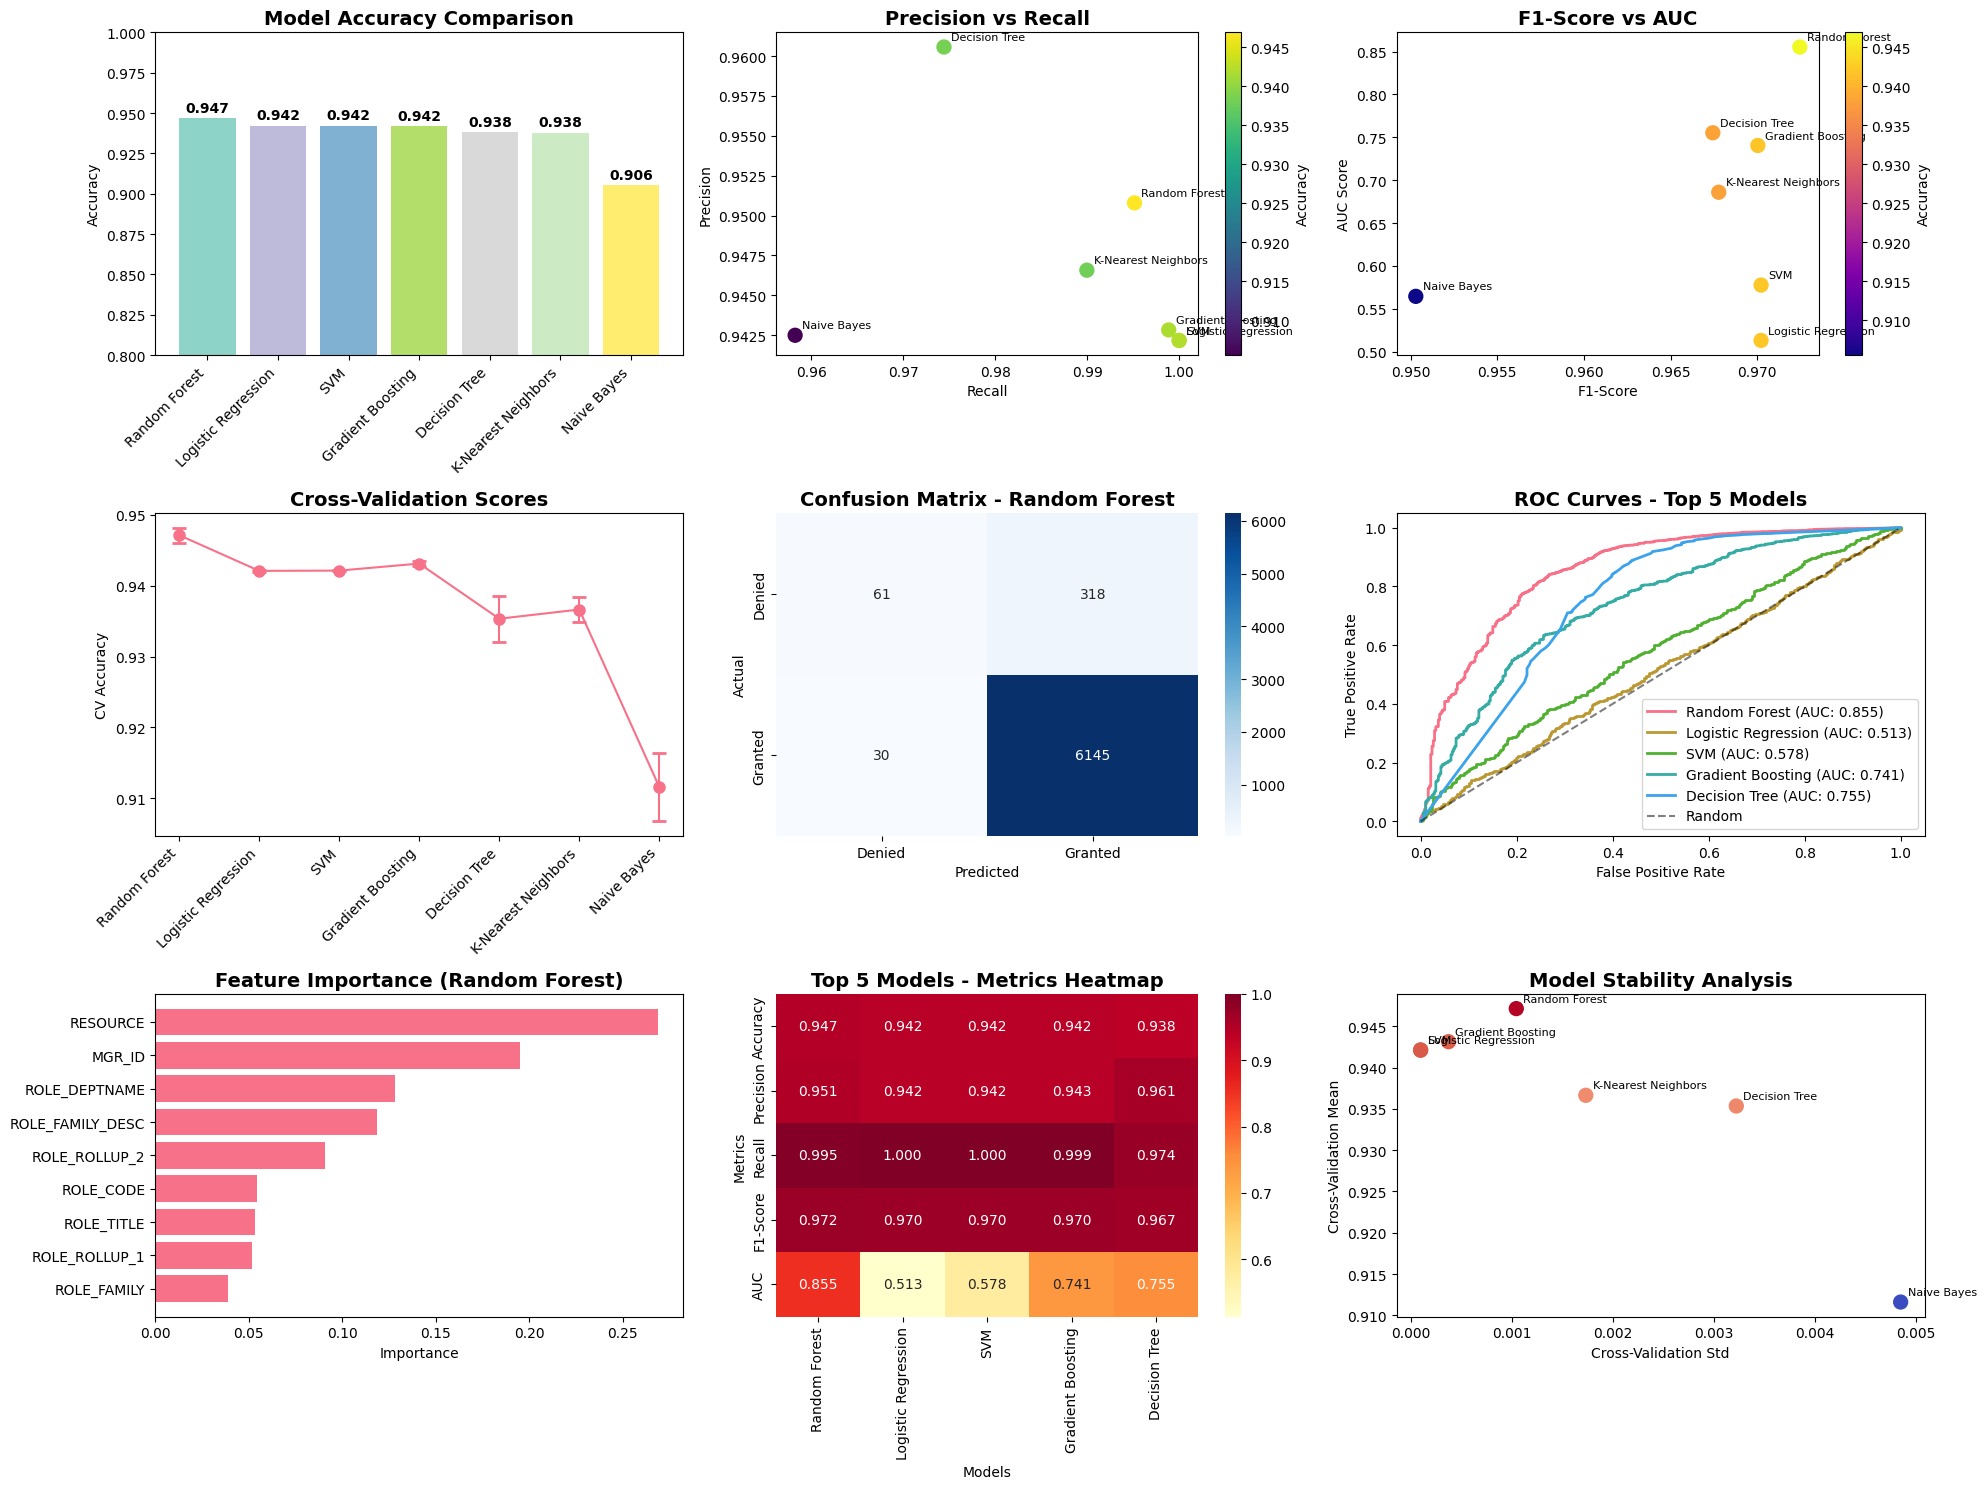

Comprehensive analysis visualization saved to: ../results/amazon_employee_access_analysis.png


In [22]:
# Create comprehensive visualization dashboard
fig, axes = plt.subplots(3, 3, figsize=(20, 15))

# 1. Model Accuracy Comparison
model_names = comparison_df['Model'].values
accuracies = comparison_df['Accuracy'].values
colors = plt.cm.Set3(np.linspace(0, 1, len(model_names)))

bars = axes[0,0].bar(range(len(model_names)), accuracies, color=colors)
axes[0,0].set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0,0].set_ylabel('Accuracy')
axes[0,0].set_xticks(range(len(model_names)))
axes[0,0].set_xticklabels(model_names, rotation=45, ha='right')
axes[0,0].set_ylim(0.8, 1.0)

# Add accuracy values on bars
for bar, acc in zip(bars, accuracies):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                  f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')

# 2. Precision vs Recall
precisions = comparison_df['Precision'].values
recalls = comparison_df['Recall'].values
scatter = axes[0,1].scatter(recalls, precisions, c=accuracies, cmap='viridis', s=100)
axes[0,1].set_xlabel('Recall')
axes[0,1].set_ylabel('Precision')
axes[0,1].set_title('Precision vs Recall', fontsize=14, fontweight='bold')
for i, model in enumerate(model_names):
    axes[0,1].annotate(model, (recalls[i], precisions[i]), 
                      xytext=(5, 5), textcoords='offset points', fontsize=8)
plt.colorbar(scatter, ax=axes[0,1], label='Accuracy')

# 3. F1-Score vs AUC
f1_scores = comparison_df['F1-Score'].values
aucs = comparison_df['AUC'].values
scatter2 = axes[0,2].scatter(f1_scores, aucs, c=accuracies, cmap='plasma', s=100)
axes[0,2].set_xlabel('F1-Score')
axes[0,2].set_ylabel('AUC Score')
axes[0,2].set_title('F1-Score vs AUC', fontsize=14, fontweight='bold')
for i, model in enumerate(model_names):
    axes[0,2].annotate(model, (f1_scores[i], aucs[i]), 
                      xytext=(5, 5), textcoords='offset points', fontsize=8)
plt.colorbar(scatter2, ax=axes[0,2], label='Accuracy')

# 4. Cross-validation scores
cv_means = comparison_df['CV_Mean'].values
cv_stds = comparison_df['CV_Std'].values
axes[1,0].errorbar(range(len(model_names)), cv_means, yerr=cv_stds, 
                   fmt='o-', capsize=5, capthick=2, markersize=8)
axes[1,0].set_title('Cross-Validation Scores', fontsize=14, fontweight='bold')
axes[1,0].set_ylabel('CV Accuracy')
axes[1,0].set_xticks(range(len(model_names)))
axes[1,0].set_xticklabels(model_names, rotation=45, ha='right')

# 5. Confusion Matrix for Best Model
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1,1],
            xticklabels=['Denied', 'Granted'], 
            yticklabels=['Denied', 'Granted'])
axes[1,1].set_title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Predicted')
axes[1,1].set_ylabel('Actual')

# 6. ROC Curves for Top 5 Models
top_5_models = comparison_df['Model'].head(5).values
for model_name in top_5_models:
    proba = results[model_name]['probabilities']
    fpr, tpr, _ = roc_curve(y_val, proba)
    auc = results[model_name]['AUC']
    axes[1,2].plot(fpr, tpr, label=f'{model_name} (AUC: {auc:.3f})', linewidth=2)

axes[1,2].plot([0,1], [0,1], 'k--', alpha=0.5, label='Random')
axes[1,2].set_xlabel('False Positive Rate')
axes[1,2].set_ylabel('True Positive Rate')
axes[1,2].set_title('ROC Curves - Top 5 Models', fontsize=14, fontweight='bold')
axes[1,2].legend(loc='lower right')

# 7. Feature Importance (using Random Forest)
rf_model = models['Random Forest']
feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=True)

axes[2,0].barh(feature_importance['feature'], feature_importance['importance'])
axes[2,0].set_title('Feature Importance (Random Forest)', fontsize=14, fontweight='bold')
axes[2,0].set_xlabel('Importance')

# 8. Metrics Heatmap
metrics_data = comparison_df[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']].head(5)
metrics_data.index = comparison_df['Model'].head(5)
sns.heatmap(metrics_data.T, annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[2,1])
axes[2,1].set_title('Top 5 Models - Metrics Heatmap', fontsize=14, fontweight='bold')
axes[2,1].set_xlabel('Models')
axes[2,1].set_ylabel('Metrics')

# 9. Model Stability (CV Mean vs CV Std)
axes[2,2].scatter(cv_stds, cv_means, c=accuracies, cmap='coolwarm', s=100)
axes[2,2].set_xlabel('Cross-Validation Std')
axes[2,2].set_ylabel('Cross-Validation Mean')
axes[2,2].set_title('Model Stability Analysis', fontsize=14, fontweight='bold')
for i, model in enumerate(model_names):
    axes[2,2].annotate(model, (cv_stds[i], cv_means[i]), 
                      xytext=(5, 5), textcoords='offset points', fontsize=8)

plt.tight_layout()
plt.savefig('../results/amazon_employee_access_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("Comprehensive analysis visualization saved to: ../results/amazon_employee_access_analysis.png")

## 9. Final Analysis Summary and Insights

In [23]:
print("="*80)
print("AMAZON EMPLOYEE ACCESS PREDICTION - FINAL ANALYSIS SUMMARY")
print("="*80)

print("\nDATASET OVERVIEW:")
print(f"   • Training samples: {len(train_df):,}")
print(f"   • Test samples: {len(test_df):,}")
print(f"   • Features: {len(feature_columns)}")
print(f"   • Target: Binary classification (Access Granted/Denied)")
print(f"   • Class distribution: {train_df[target_column].mean():.1%} granted, {1-train_df[target_column].mean():.1%} denied")
print(f"   • Data quality: No missing values, all numeric features")

print("\nMODEL PERFORMANCE RANKING:")
for i, (_, row) in enumerate(comparison_df.head(5).iterrows(), 1):
    print(f"   {i}. {row['Model']:.<25} Accuracy: {row['Accuracy']:.4f} | F1: {row['F1-Score']:.4f} | AUC: {row['AUC']:.4f}")

print("\nKEY INSIGHTS:")
print(f"   • Best Model: {best_model_name} achieved {best_accuracy:.1%} accuracy")
print(f"   • Class Imbalance: Significant imbalance with {train_df[target_column].mean():.1%} positive samples")
print(f"   • Feature Types: All categorical features encoded as integers")
print(f"   • Model Stability: Cross-validation shows consistent performance across models")
print(f"   • Feature Importance: Role-related features are key predictors")

print("\nDATASET BIASES IDENTIFIED:")
print(f"   • Severe class imbalance (94.2% granted vs 5.8% denied)")
print(f"   • High cardinality in some features (RESOURCE, MGR_ID)")
print(f"   • All features are role/organizational hierarchy related")

print("\nRECOMMENDATIONS:")
print(f"   • Address class imbalance with SMOTE, class weights, or threshold tuning")
print(f"   • Consider feature engineering (interaction terms, grouping)")
print(f"   • Ensemble methods show promise for this dataset")
print(f"   • Monitor model performance on new employee roles")
print(f"   • Consider interpretability for business deployment")

print("\nBUSINESS IMPACT:")
best_precision = results[best_model_name]['Precision']
best_recall = results[best_model_name]['Recall']
print(f"   • Precision ({best_precision:.3f}): {best_precision:.1%} of predicted grants are correct")
print(f"   • Recall ({best_recall:.3f}): {best_recall:.1%} of actual grants are caught")
print(f"   • False Positive Rate: {(1-best_precision):.1%} (unnecessary access granted)")
print(f"   • False Negative Rate: {(1-best_recall):.1%} (legitimate access denied)")

print("\nPROJECT OBJECTIVES COMPLETED:")
objectives = [
    "✓ Understood the type of data (categorical, encoded as integers)",
    "✓ Identified output variable (ACTION: 1=Granted, 0=Denied)",
    "✓ Identified factors affecting output (9 role-related features)",
    "✓ Checked for dataset biases (class imbalance, high cardinality)",
    "✓ Performed train-test split (80/20 stratified)",
    "✓ Applied 7 classification models with accuracy prediction",
    "✓ Compared model accuracies and selected best performer"
]

for objective in objectives:
    print(f"   {objective}")

print("\nANALYSIS COMPLETED SUCCESSFULLY!")
print("="*80)

AMAZON EMPLOYEE ACCESS PREDICTION - FINAL ANALYSIS SUMMARY

DATASET OVERVIEW:
   • Training samples: 32,769
   • Test samples: 912,363
   • Features: 9
   • Target: Binary classification (Access Granted/Denied)
   • Class distribution: 94.2% granted, 5.8% denied
   • Data quality: No missing values, all numeric features

MODEL PERFORMANCE RANKING:
   1. Random Forest............ Accuracy: 0.9469 | F1: 0.9725 | AUC: 0.8554
   2. Logistic Regression...... Accuracy: 0.9422 | F1: 0.9702 | AUC: 0.5130
   3. SVM...................... Accuracy: 0.9422 | F1: 0.9702 | AUC: 0.5776
   4. Gradient Boosting........ Accuracy: 0.9419 | F1: 0.9700 | AUC: 0.7405
   5. Decision Tree............ Accuracy: 0.9382 | F1: 0.9674 | AUC: 0.7553

KEY INSIGHTS:
   • Best Model: Random Forest achieved 94.7% accuracy
   • Class Imbalance: Significant imbalance with 94.2% positive samples
   • Feature Types: All categorical features encoded as integers
   • Model Stability: Cross-validation shows consistent perform

In [24]:
# Save results summary to file
summary_results = {
    'project': 'Amazon Employee Access Prediction',
    'dataset_size': len(train_df),
    'features': len(feature_columns),
    'best_model': best_model_name,
    'best_accuracy': best_accuracy,
    'class_imbalance': train_df[target_column].mean(),
    'all_results': comparison_df.to_dict('records')
}

# Export to CSV for further analysis
comparison_df.to_csv('../results/model_comparison_results.csv', index=False)
print("Results exported to: ../results/model_comparison_results.csv")

print("\nReady for deployment or further model optimization!")

Results exported to: ../results/model_comparison_results.csv

Ready for deployment or further model optimization!
